# Exploration of new definition for loss

We model the detector signal $x_{it}$ at pixel $i$ and shot $t$ as a combination of:

$$\boxed{x_{it} = \tau_i \cdot F_t A_i\, S(q_i;\theta_{c_t}) \;+\; F_t J_i \;+\; \varepsilon_{it}}$$

| symbol | meaning | status |
| ---------------------------- | -------------------------- | ----------------------------------------- |
| $F_t$ | incident flux, shot $t$ | **measured** (monitors) |
| $A_i = \Omega_i P(\chi_i,q_i)$ | solid angle × polarization | **known** from calibration |
| $S(q;\theta_c)$ | isotropic scattering | unknown, **condition-dependent** |
| $\tau_i \in [0,1]$ | transmission — shadows | unknown, static, **multiplicative** |
| $J_i \ge 0$ | parasitic scattering — streaks | unknown, static, **additive** |
| $\varepsilon_{it}$ | Poisson + read | variance estimable |

$$M = \{i : \tau_i \ne 1\} \;\cup\; \{i : J_i \ne 0\}$$

Detector defects are **out of scope**: already removed by the calib + geometry floor.

## Definition of conditions

Conditions correspond to different values in the shots metadata. Different conditions map directly to different shot selections. In practice this gives us two conditions :
1. VCC "on"
2. VCC "off"

As a first approximation, we will artificially create more different conditions by just decomposing each conditions in continuous folds (not the way `create_K_folds` work). In practice, we divide each the VCC "on" group into 20 differents subgroups and VCC "off" into 2 different subgroups.

## Per condition

For pixel $i$, condition $c$, and shots $t \in T_c$, first divide out the measured incident flux (otherwise shots with different $F_t$ do not share one line):
$$
\bar z_i^{(c)} := \frac{1}{|T_c|}\sum_{t\in T_c} \frac{x_{it}}{F_t} = \tau_i A_i \cdot \, S(q_i;\theta_c) + J_i \;+\; \bar\varepsilon_i^{(c)}.
$$
For $i$ fixed and $c$ varying, we expect to observe a straight line in the $(S(q_i;\theta_c), \bar z_i^{(c)})$ plane, with slope $\tau_i A_i$ and intercept $J_i$. The slope is the *transmission* and the intercept is the *parasitic scattering*.

[psana] opening 1 streams for run 389


2026-08-05 04:42:56.910 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc


[scan] run 0389: 697 shots read (beam 99.3%, CC open 100.0%, VCC open 89.7%)
[psana] opening 1 streams for run 389


2026-08-05 04:43:22.340 [WRN] {XtcInput.DgHeader} DgHeader.cpp:99 - EOF while reading datagram payload from file: /users/eleves-a/2022/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0389-s03-c00.xtc


Decoded frames per condition: [32, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 36, 35]


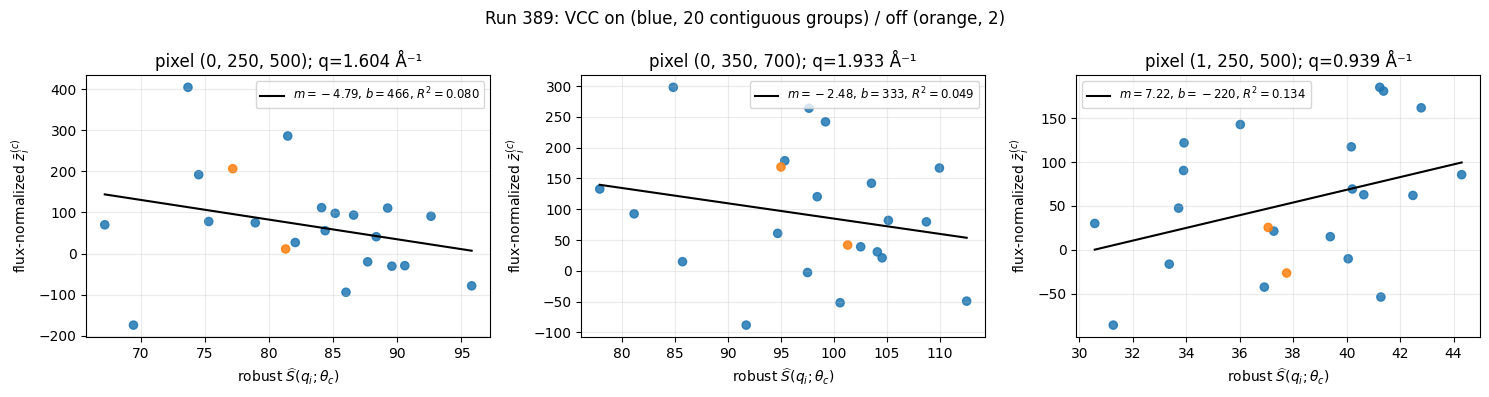

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from automask import azimuthal, geometry
from automask.io.read_xtc import iter_calibrated
from automask.shot_selection import Condition, ShotSelection
from automask.utils import profile_run_values

# This cell needs the psana kernel and the local XTC / calibration layout.
os.environ.setdefault('SIT_PSDM_DATA', '/Data/hippolyte.wallaert/psdm')
os.environ.setdefault('SIT_ROOT', os.path.join(os.environ['SIT_PSDM_DATA'], 'sit_root'))
os.environ.setdefault('SIT_DATA', os.path.join(os.environ['SIT_PSDM_DATA'], 'data'))

RUN = 389
N_VCC_ON, N_VCC_OFF = 20, 2
MONITOR = 'diodeU/channels[0]'  # downstream of the CC/VCC split
# Native (panel, row, column) pixels.  Replace these after inspecting a run image.
PIXELS = [(0, 250, 500), (0, 350, 700), (1, 250, 500)]
N_Q_BINS = 160

run_profile = profile_run_values(RUN, show=False)
BEAM = 'DetInfo(NoDetector.0:Evr.0)/EvrData.DataV4/eventCode[137]'
VCC = 'ai/ch03'
base_conditions = (Condition(BEAM, '==', 1), Condition(MONITOR, 'nonzero'))
vcc_on_selection = ShotSelection(where=base_conditions + (Condition(VCC, '>', 2.0),))
vcc_off_selection = ShotSelection(where=base_conditions + (Condition(VCC, '<=', 2.0),))
vcc_on = vcc_on_selection.resolve(run_profile)
vcc_off = vcc_off_selection.resolve(run_profile)
flux = run_profile.column(MONITOR)
if min(vcc_on.size, vcc_off.size) == 0:
    raise RuntimeError('No usable shots in one VCC state; choose another run or monitor.')

# array_split preserves stream order, unlike create_k_folds' round-robin split.
groups = [g for g in np.array_split(vcc_on, N_VCC_ON) if g.size]
groups += [g for g in np.array_split(vcc_off, N_VCC_OFF) if g.size]
labels = np.full(run_profile.events, -1, dtype=np.int16)
for group, events in enumerate(groups):
    labels[events] = group

group_sums = np.zeros((len(groups), 2, 512, 1024), dtype=np.float64)
decoded = np.zeros(len(groups), dtype=np.int64)
for event, frame in iter_calibrated(
    RUN, np.concatenate(groups), source=run_profile.source
):
    group = labels[event]
    group_sums[group] += frame / flux[event]
    decoded[group] += 1
if np.any(decoded == 0):
    raise RuntimeError(f'No calibrated frames decoded for groups {np.flatnonzero(decoded == 0).tolist()}')
zbar = group_sums / decoded[:, None, None, None]

# Estimate S(q; theta_c) from the robust azimuthal median of zbar/A.
# This is an estimate, so a straight plot supports the model but cannot prove it.
ai = azimuthal.integrator(RUN)
q = geometry.asm_to_panel(ai.array_from_unit(unit='q_A^-1'), RUN)
A = geometry.asm_to_panel(
    ai.solidAngleArray() * ai.polarization(factor=azimuthal.POLARIZATION), RUN
)
valid = np.isfinite(q) & np.isfinite(A) & (A > 0)
q_edges = np.linspace(np.nanmin(q[valid]), np.nanmax(q[valid]), N_Q_BINS + 1)
q_bin = np.clip(np.digitize(q, q_edges) - 1, 0, N_Q_BINS - 1)
flat_valid = np.flatnonzero(valid.ravel())
order = np.argsort(q_bin.ravel()[flat_valid], kind='stable')
ordered_pixels = flat_valid[order]
ordered_bins = q_bin.ravel()[ordered_pixels]
bounds = np.searchsorted(ordered_bins, np.arange(N_Q_BINS + 1))
S = np.full((len(groups), N_Q_BINS), np.nan)
for group in range(len(groups)):
    ratio = (zbar[group] / A).ravel()[ordered_pixels]
    for bin_index in range(N_Q_BINS):
        values = ratio[bounds[bin_index]:bounds[bin_index + 1]]
        S[group, bin_index] = np.nanmedian(values)

fig, axes = plt.subplots(1, len(PIXELS), figsize=(5 * len(PIXELS), 4), squeeze=False)
colors = np.array(['tab:blue'] * N_VCC_ON + ['tab:orange'] * N_VCC_OFF)[:len(groups)]
for ax, pixel in zip(axes.flat, PIXELS):
    if len(pixel) != 3 or any(not isinstance(v, (int, np.integer)) for v in pixel):
        raise TypeError('PIXELS entries must be native (panel, row, column) integer tuples.')
    p, row, col = pixel
    if not (0 <= p < 2 and 0 <= row < 512 and 0 <= col < 1024):
        raise ValueError(f'{pixel} is outside the Jungfrau panel shape (2, 512, 1024).')
    s = S[:, q_bin[p, row, col]]
    y = zbar[:, p, row, col]
    keep = np.isfinite(s) & np.isfinite(y)
    slope, intercept = np.polyfit(s[keep], y[keep], 1)
    prediction = slope * s[keep] + intercept
    r2 = 1 - np.sum((y[keep] - prediction) ** 2) / np.sum((y[keep] - y[keep].mean()) ** 2)
    ax.scatter(s, y, c=colors, s=35, alpha=0.85)
    xline = np.linspace(np.nanmin(s[keep]), np.nanmax(s[keep]), 100)
    ax.plot(xline, slope * xline + intercept, color='black', lw=1.5,
            label=fr'$m={slope:.3g}$, $b={intercept:.3g}$, $R^2={r2:.3f}$')
    ax.set(title=f'pixel {pixel}; q={q[p, row, col]:.3f} Å⁻¹',
           xlabel=r'robust $\widehat{S}(q_i;\theta_c)$',
           ylabel=r'flux-normalized $\bar z_i^{(c)}$')
    ax.grid(alpha=0.25)
    ax.legend(fontsize='small')

fig.suptitle(f'Run {RUN}: VCC on (blue, {N_VCC_ON} contiguous groups) / off (orange, {N_VCC_OFF})')
fig.tight_layout()
print('Decoded frames per condition:', decoded.tolist())
